## Visualizations in Python
Go through analysis and visuals to gain insight on performance
Import csv and correct libs

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm
# from datetime import date, time

df = pd.read_csv(r'C:\Users\Kat\Documents\repos\flight-performance-analysis\clean_data\merged_flights.csv')

### Exploratory Analysis 
1. Which months/seasons have the most delays and why (answered with correlation)? Use a bar chart for months and pie chart for season

    MONTH   TOTAL   DELAYED  DELAY_RATE
0       1  539747   95660.0   17.723118
1       2  504884   97820.0   19.374747
2       3  600872  113973.0   18.967933
3       4  583950  108455.0   18.572652
4       5  605648  135037.0   22.296284
5       6  611575  165475.0   27.057188
6       7  631428  176520.0   27.955681
7       8  602378  133299.0   22.128796
8       9  562439   92348.0   16.419203
9      10  605844  118158.0   19.503040
10     11  570550  110867.0   19.431601


C:\Users\Kat\AppData\Local\Temp\ipykernel_24104\2951524828.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


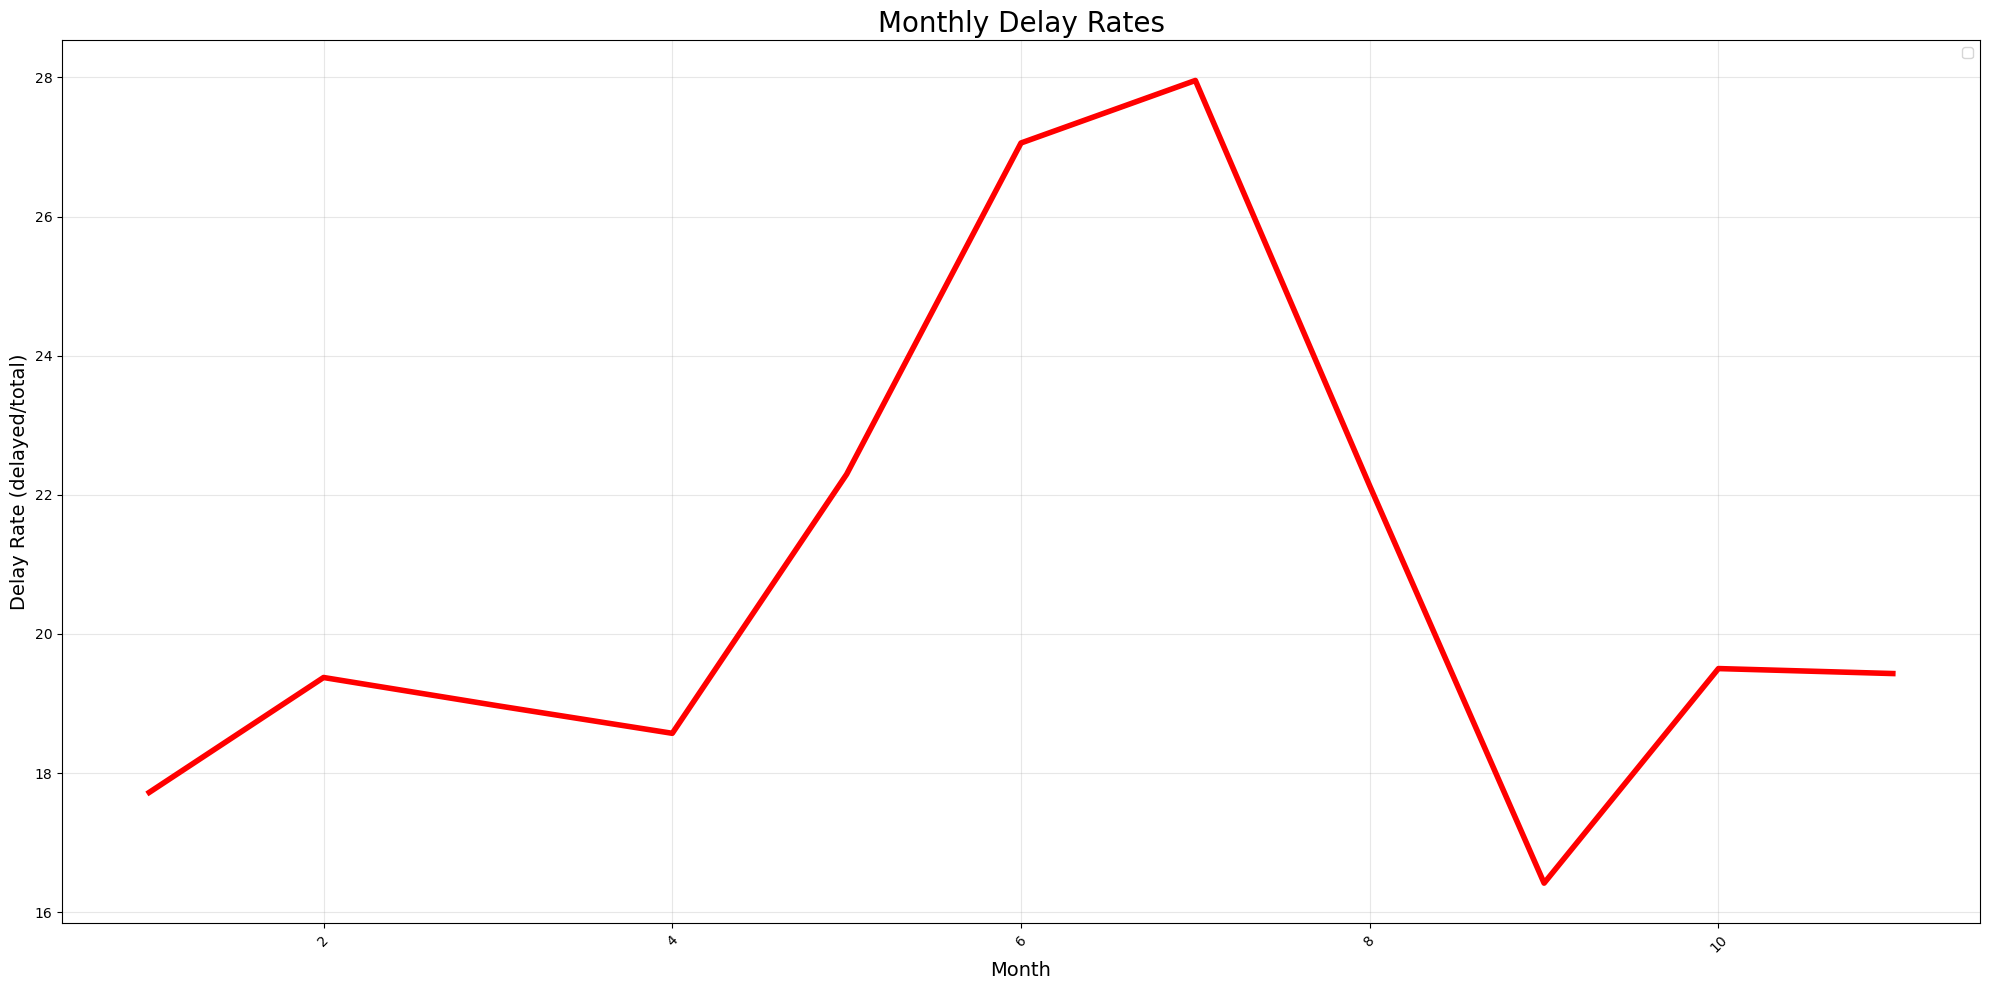

   SEASON    TOTAL   DELAYED  DELAY_RATE
0    Fall  1738833  321373.0   18.482108
1  Spring  1790470  357465.0   19.964870
2  Summer  1845381  475294.0   25.755874
3  Winter  1044631  193480.0   18.521373


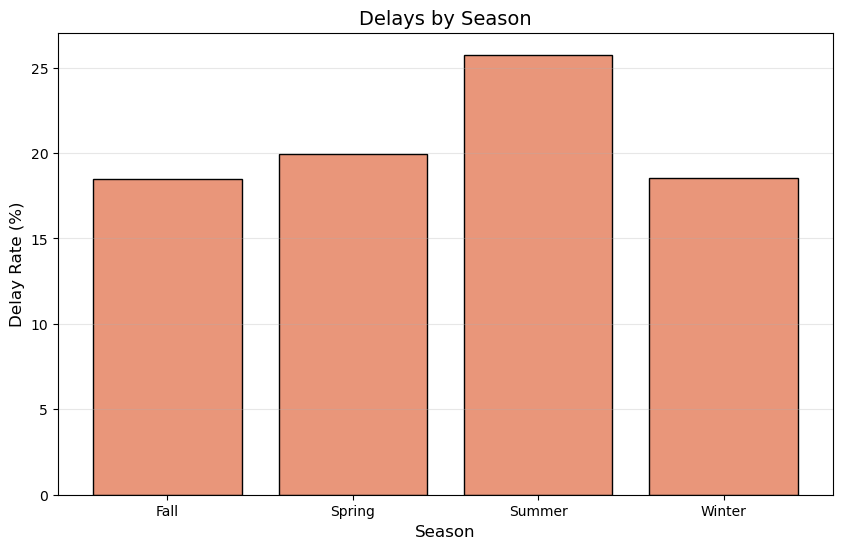

In [7]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month # as int

month_to_season = {
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall",
    12: "Winter",
}
df["SEASON"] = df['MONTH'].map(month_to_season)

month_delays = df.groupby('MONTH')['DEP_DEL15'].agg(TOTAL="count",DELAYED="sum").reset_index().sort_values('MONTH')
month_delays['DELAY_RATE'] = month_delays['DELAYED']/month_delays['TOTAL'] * 100
print(month_delays)


plt.figure(figsize=(20, 10))
plt.plot(month_delays['MONTH'], month_delays['DELAY_RATE'], linewidth=4, color='red', label='')
plt.title('Monthly Delay Rates', fontsize=20)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Delay Rate (delayed/total)', fontsize=14)
plt.legend()

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

season_delays = df.groupby('SEASON')['DEP_DEL15'].agg(TOTAL="count",DELAYED="sum").reset_index().sort_values('SEASON')
season_delays['DELAY_RATE'] = season_delays['DELAYED']/season_delays['TOTAL'] * 100
print(season_delays)

plt.figure(figsize=(10, 6))
plt.bar(season_delays['SEASON'], season_delays['DELAY_RATE'], color='darksalmon', edgecolor='black', alpha=1.0)

# Add labels and a title
plt.xlabel("Season", fontsize=12)
plt.ylabel("Delay Rate (%)", fontsize=12)
plt.title("Delays by Season", fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# Display the chart
plt.show()


2. Which regions have the most delays? Use a map and list from greatest to least 

Top 15 Regions with Most Delays:
    ORIGIN   TOTAL  DELAYED  DELAY_RATE
90     DFW  290084  80163.0       27.63
89     DEN  291660  73517.0       25.21
242    ORD  299238  71124.0       23.77
20     ATL  288669  66140.0       22.91
70     CLT  180450  41998.0       23.27
185    LAS  169256  38760.0       22.90
253    PHX  179067  36942.0       20.63
207    MCO  145761  34532.0       23.69
86     DCA  131198  31756.0       24.20
299    SEA  151812  31120.0       20.50
187    LAX  174422  30478.0       17.47
44     BOS  131611  28981.0       22.02
196    LGA  124364  25969.0       20.88
219    MIA  101808  25381.0       24.93
162    IAH  107288  24461.0       22.80

Total regions analyzed: 350


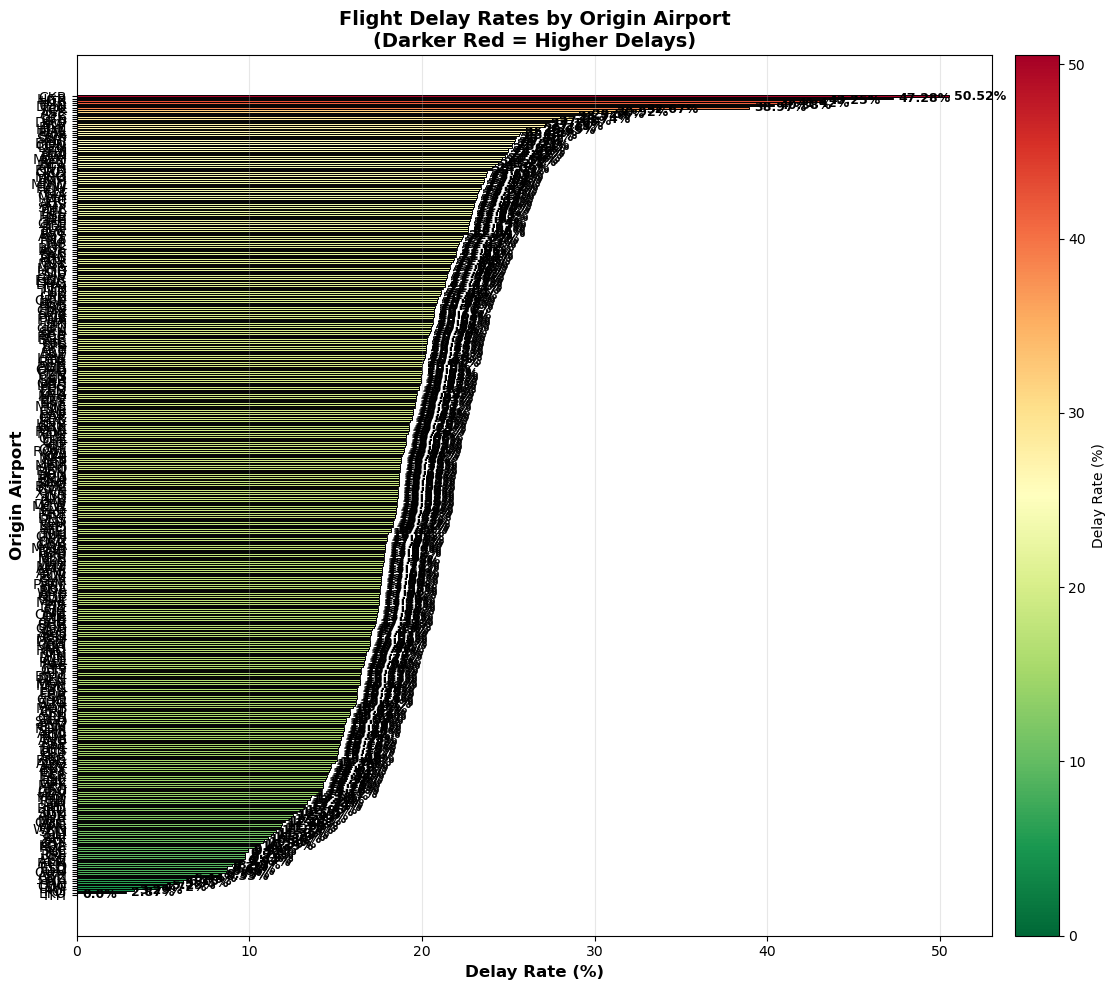


Delay Rate Summary:
Highest: 50.52% at CKB
Lowest: 0.00% at ITH
Average: 18.67%


In [ ]:
# analyze delays by origin airport
region_delays = df.groupby('ORIGIN')['DEP_DEL15'].agg(TOTAL="count", DELAYED="sum").reset_index().sort_values('DELAYED', ascending=False)
region_delays['DELAY_RATE'] = (region_delays['DELAYED'] / region_delays['TOTAL'] * 100).round(2)

print("Top 15 Airports with Most Delays:")
print(region_delays.head(15))
print(f"\nTotal Number of Airports Analyzed: {len(region_delays)}")

# fig, ax = plt.subplots(figsize=(12, 10))

# # Sort by delay rate for better visualization
# region_delays_sorted = region_delays.sort_values('DELAY_RATE', ascending=True)

# # Use a colormap to shade bars based on delay rate
# colors = plt.cm.RdYlGn_r(region_delays_sorted['DELAY_RATE'] / region_delays_sorted['DELAY_RATE'].max())

# bars = ax.barh(region_delays_sorted['ORIGIN'], region_delays_sorted['DELAY_RATE'], color=colors, edgecolor='black', linewidth=0.7)

# # Add colorbar to show the mapping between colors and delay percentage
# sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=plt.Normalize(vmin=region_delays_sorted['DELAY_RATE'].min(), vmax=region_delays_sorted['DELAY_RATE'].max()))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, label='Delay Rate (%)', pad=0.02)

# # Add percentage labels on the bars
# for i, (bar, rate) in enumerate(zip(bars, region_delays_sorted['DELAY_RATE'])):
#     ax.text(rate + 0.3, bar.get_y() + bar.get_height()/2, f'{rate}%', 
#             va='center', fontsize=9, fontweight='bold')

# ax.set_xlabel('Delay Rate (%)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Origin Airport', fontsize=12, fontweight='bold')
# ax.set_title('Flight Delay Rates by Origin Airport\n(Darker Red = Higher Delays)', fontsize=14, fontweight='bold')
# ax.grid(True, alpha=0.3, axis='x')

# plt.tight_layout()
# plt.show()

# # Additional summary statistics
# print(f"\nDelay Rate Summary:")
# print(f"Highest: {region_delays['DELAY_RATE'].max():.2f}% at {region_delays.loc[region_delays['DELAY_RATE'].idxmax(), 'ORIGIN']}")
# print(f"Lowest: {region_delays['DELAY_RATE'].min():.2f}% at {region_delays.loc[region_delays['DELAY_RATE'].idxmin(), 'ORIGIN']}")
# print(f"Average: {region_delays['DELAY_RATE'].mean():.2f}%")


### Descriptive Analysis 
1. What is the average delay time per airline? Pick the region that is busiest and focus on airlines outgoing